# Incremental Updates: Keeping Market Data Fresh

**Docker image**: `ml4t`

**Purpose**: Walk through the update lifecycle — initial load, daily delta,
gap detection, and a small health dashboard — so the same flow that runs
in `data/download_all.py --update` is visible end-to-end.

**Learning objectives**:
1. Compare full-refresh and incremental update costs.
2. Drive a daily delta with `DataManager.update(..., fill_gaps=False)` and
   understand why the `fill_gaps=True` default is unsafe for OHLCV data.
3. Verify completeness with `GapDetector(exclude_weekends=True)`.
4. Render a 3-panel health dashboard (volume, freshness, issues).

**Book reference**: §2.4 (storing data) — operational counterpart to the
storage benchmarks in notebooks 20 and 21.

**Prerequisites**: ml4t-data installed; live network access for Yahoo Finance.

**Why incremental updates**: a full refresh of 500 symbols × 10 years pulls
~1.26M rows; an incremental run pulls roughly the trading days since the
last fetch. The gap is two orders of magnitude in network and disk I/O.

## Setup

In [1]:
"""Incremental Updates — Keeping market data fresh with daily delta fetches."""

import logging
import shutil
from datetime import datetime

import matplotlib.pyplot as plt
import polars as pl
import structlog

# Quiet ml4t-data's structured logger so the notebook focuses on demo output.
structlog.configure(
    wrapper_class=structlog.make_filtering_bound_logger(logging.WARNING),
)

from ml4t.data import DataManager
from ml4t.data.storage import HiveStorage
from ml4t.data.storage.backend import StorageConfig
from ml4t.data.update_manager import GapDetector
from ml4t.data.validation import OHLCVValidator

from utils.paths import get_output_dir
from utils.style import COLORS

# Storage for this notebook's demos. Wipe any prior-run artifacts so the
# initial-load + update sequence is reproducible.
DEMO_DIR = get_output_dir(2, "incremental_updates")
if DEMO_DIR.exists():
    shutil.rmtree(DEMO_DIR)
DEMO_DIR.mkdir(parents=True, exist_ok=True)

print(f"Demo storage: {DEMO_DIR}")

.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:35: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be rem

Demo storage: 02_financial_data_universe/output/incremental_updates


In [2]:
# Production defaults — Papermill injects overrides for CI

---

## 1. Full Refresh vs Incremental Update

Let's demonstrate the difference with a concrete example.

### Step 1: Initial Load (Full History)

In [3]:
# Initialize storage and DataManager
config = StorageConfig(base_path=DEMO_DIR / "updates_demo", compression="zstd")
storage = HiveStorage(config=config)
dm = DataManager(storage=storage)

symbols = ["AAPL", "MSFT", "GOOGL"]

print("=== Initial Load (Full History) ===")
for symbol in symbols:
    dm.load(symbol, "2023-01-01", "2024-12-31", provider="yahoo")
    meta = dm.get_metadata(symbol)
    print(f"  {symbol}: stored ({meta['row_count']} rows)")

=== Initial Load (Full History) ===


  AAPL: stored (502 rows)
  MSFT: stored (502 rows)


  GOOGL: stored (502 rows)


### Step 2: Incremental Update (Only New Data)

`DataManager.update()` reads the last timestamp in storage, refetches a small
overlap (`lookback_days=7`) plus everything since, and merges. We pass
`fill_gaps=False` deliberately — the library default `fill_gaps=True` runs a
calendar-unaware gap detector that treats every weekend and US holiday as a
missing trading day and forward-fills it, silently inflating each symbol's
row count by hundreds of phantom bars. For OHLCV data, the right behavior is
to leave non-trading days absent and rely on a calendar-aware completeness
check downstream.

In [4]:
print("=== Incremental Update ===")
for symbol in symbols:
    dm.update(symbol, lookback_days=7, provider="yahoo", fill_gaps=False)
    meta = dm.get_metadata(symbol)
    print(f"  {symbol}: updated ({meta['row_count']} rows)")

=== Incremental Update ===
  AAPL: updated (864 rows)


  MSFT: updated (864 rows)
  GOOGL: updated (864 rows)


Each symbol started with 502 rows (2023-01 through 2024-12). The update
fetches the 7-day overlap plus all sessions through today and merges; the
resulting row count equals the original 502 plus exactly the new trading
sessions — no synthetic weekend/holiday rows.

---

## 2. Update Strategies

ml4t-data supports four strategies for different scenarios:

In [5]:
pl.DataFrame(
    {
        "strategy": ["INCREMENTAL", "APPEND_ONLY", "FULL_REFRESH", "BACKFILL"],
        "behavior": [
            "Fetch data after last stored timestamp",
            "Add new rows; never modify existing",
            "Re-download and replace all data",
            "Fetch missing periods inside existing range",
        ],
        "use_case": [
            "Daily updates (default, fastest)",
            "Audit-safe archives",
            "Recovery after corruption",
            "Patch holes in historical data",
        ],
    }
)

strategy,behavior,use_case
str,str,str
"""INCREMENTAL""","""Fetch data after last stored t…","""Daily updates (default, fastes…"
"""APPEND_ONLY""","""Add new rows; never modify exi…","""Audit-safe archives"""
"""FULL_REFRESH""","""Re-download and replace all da…","""Recovery after corruption"""
"""BACKFILL""","""Fetch missing periods inside e…","""Patch holes in historical data"""


The `IncrementalUpdater` class provides low-level control over these strategies.
For most use cases, `DataManager.update()` (which uses `INCREMENTAL`) is sufficient.

---

## 3. Gap Detection

Before running a backtest, verify that your data is complete.
Gaps can occur from failed downloads, provider outages, or holiday handling.

In [6]:
gap_detector = GapDetector(exclude_weekends=True)

print("=== Gap Detection ===")
for symbol in symbols:
    key = f"equities/daily/{symbol}"
    df = storage.read(key).collect()
    gaps = gap_detector.detect_gaps(df, frequency="daily")
    if gaps:
        print(f"{symbol}: {len(gaps)} gap(s) found")
        for gap in gaps[:5]:
            print(f"  {gap['start'].date()} -> {gap['end'].date()} ({gap['size_days']} days)")
        if len(gaps) > 5:
            print(f"  ... and {len(gaps) - 5} more")
    else:
        print(f"{symbol}: complete (no gaps)")

=== Gap Detection ===
AAPL: 35 gap(s) found
  2023-01-16 -> 2023-01-16 (1 days)
  2023-02-20 -> 2023-02-20 (1 days)
  2023-04-07 -> 2023-04-07 (1 days)
  2023-05-29 -> 2023-05-29 (1 days)
  2023-06-19 -> 2023-06-19 (1 days)
  ... and 30 more
MSFT: 35 gap(s) found
  2023-01-16 -> 2023-01-16 (1 days)
  2023-02-20 -> 2023-02-20 (1 days)
  2023-04-07 -> 2023-04-07 (1 days)
  2023-05-29 -> 2023-05-29 (1 days)
  2023-06-19 -> 2023-06-19 (1 days)
  ... and 30 more
GOOGL: 35 gap(s) found
  2023-01-16 -> 2023-01-16 (1 days)
  2023-02-20 -> 2023-02-20 (1 days)
  2023-04-07 -> 2023-04-07 (1 days)
  2023-05-29 -> 2023-05-29 (1 days)
  2023-06-19 -> 2023-06-19 (1 days)
  ... and 30 more


`exclude_weekends=True` filters Saturdays and Sundays. US market holidays
(MLK Day, Good Friday, Thanksgiving, etc.) still register as one-day gaps
because the detector has no exchange calendar — fine for routine update
health checks, but pair with a calendar-aware completeness check before
trusting the result for backtest panels.

---

## 4. Data Health Dashboard

In production, monitor data health across your entire universe.

In [7]:
def data_health_report(storage: HiveStorage, symbols: list[str]) -> pl.DataFrame:
    """Per-symbol freshness, gap count, and validation issue count."""
    validator = OHLCVValidator(max_return_threshold=0.5)
    detector = GapDetector(exclude_weekends=True)
    now = datetime.now()
    rows = []
    for symbol in symbols:
        df = storage.read(f"equities/daily/{symbol}").collect()
        last_date = df["timestamp"].max().replace(tzinfo=None)
        days_stale = (now - last_date).days
        gaps = detector.detect_gaps(df, frequency="daily")
        result = validator.validate(df)
        rows.append(
            {
                "symbol": symbol,
                "status": "stale" if days_stale > 5 else "fresh",
                "rows": len(df),
                "last_date": last_date.date(),
                "days_stale": days_stale,
                "gaps": len(gaps),
                "issues": result.error_count if not result.passed else 0,
            }
        )
    return pl.DataFrame(rows)

In [8]:
report = data_health_report(storage, symbols)
report

symbol,status,rows,last_date,days_stale,gaps,issues
str,str,i64,date,i64,i64,i64
"""AAPL""","""fresh""",864,2026-06-12,0,35,1
"""MSFT""","""fresh""",864,2026-06-12,0,35,1
"""GOOGL""","""fresh""",864,2026-06-12,0,35,1


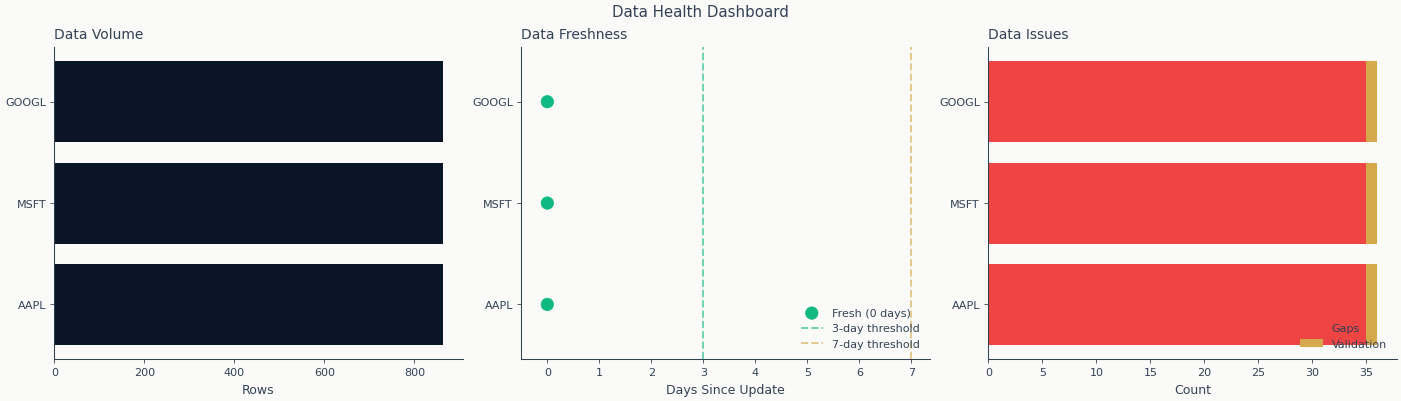

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

axes[0].barh(report["symbol"].to_list(), report["rows"].to_list(), color=COLORS["blue"])
axes[0].set_xlabel("Rows")
axes[0].set_title("Data Volume")

stale_days = report["days_stale"].to_list()
freshness_color = [
    COLORS["positive"] if d <= 3 else COLORS["amber"] if d <= 7 else COLORS["negative"]
    for d in stale_days
]
# Plot bars; zero-width bars (days_stale == 0) get a small marker so the
# panel is not blank when every symbol is fresh.
axes[1].barh(report["symbol"].to_list(), stale_days, color=freshness_color)
zero_mask = [i for i, d in enumerate(stale_days) if d == 0]
if zero_mask:
    axes[1].scatter(
        [0] * len(zero_mask),
        [report["symbol"].to_list()[i] for i in zero_mask],
        color=[freshness_color[i] for i in zero_mask],
        s=80,
        marker="o",
        zorder=3,
        label="Fresh (0 days)",
    )
axes[1].axvline(3, color=COLORS["positive"], linestyle="--", alpha=0.6, label="3-day threshold")
axes[1].axvline(7, color=COLORS["amber"], linestyle="--", alpha=0.6, label="7-day threshold")
axes[1].set_xlim(left=-0.5)
axes[1].set_xlabel("Days Since Update")
axes[1].set_title("Data Freshness")
axes[1].legend(fontsize=8, loc="lower right")

gaps = report["gaps"].to_list()
issues = report["issues"].to_list()
axes[2].barh(report["symbol"].to_list(), gaps, color=COLORS["negative"], label="Gaps")
axes[2].barh(
    report["symbol"].to_list(), issues, left=gaps, color=COLORS["amber"], label="Validation"
)
axes[2].set_xlabel("Count")
axes[2].set_title("Data Issues")
axes[2].legend(fontsize=8, loc="lower right")

fig.suptitle("Data Health Dashboard")
plt.show()

---

## 5. The Book's Update Workflow

The book's `data/download_all.py` script implements exactly this pattern
for all asset classes. Run it with `--update` to extend datasets to the present:

```bash
# Initial download (run once)
python data/download_all.py

# Update to present (run daily/weekly)
python data/download_all.py --update
```

Under the hood, `download_all.py` uses:
- `ETFDataManager.from_config("data/etfs/config.yaml")` → `manager.update()`
- `CryptoDataManager.from_config("data/crypto/config.yaml")` → `manager.update()`
- `MacroDataManager.from_config("data/macro/config.yaml")` → `manager.download_treasury_yields()`
- `FuturesDataManager.from_config("data/futures/config.yaml")` → `manager.download_all()`

Each manager reads its YAML config for symbols, date ranges, and provider settings,
then updates only what's new.

### Config-Driven Downloads

The ETF config at `data/etfs/config.yaml` defines:
```yaml
etfs:
  provider: yahoo
  start: '2006-01-01'
  end: '2025-12-31'
  frequency: daily
  tickers:
    us_equity_broad:
      symbols: [SPY, QQQ, IWM, ...]
    us_sectors:
      symbols: [XLB, XLC, XLE, ...]
    # ... 9 categories, 100 ETFs total
```

When you run `--update` in 2026+, it extends data beyond the configured end date
to the present — no config changes needed.

---

## Summary

### Key Patterns

| Pattern | Command | When |
|---------|---------|------|
| Initial load | `dm.load(symbol, start, end)` | First time |
| Daily update | `dm.update(symbol, lookback_days=7)` | Every trading day |
| Gap check | `updater.detect_gaps(df, "daily")` | Before backtesting |
| Full refresh | `UpdateStrategy.FULL_REFRESH` | After data corruption |
| Batch update | `download_all.py --update` | Cron job |

### Production Checklist

1. **Initial download**: `python data/download_all.py` (run once, ~10 min)
2. **Schedule updates**: Add `download_all.py --update` to cron (daily at 6 PM)
3. **Monitor health**: Check freshness, gaps, and validation before backtests
4. **Validate data**: Use `OHLCVValidator` on every load (see `13_data_quality_framework`)

### Key Takeaways

- **`lookback_days` is the operating lever**, not the symbol set. Set it once
  to cover provider revision windows (Yahoo retro-adjusts ~5 trading days; CRSP
  ~30) and the strategy generalizes across instruments.
- **Gap detection runs against stored data, not stream data.** A daily cron
  that finishes with `detect_gaps()` catches missed trading days before any
  backtest reads stale partitions.
- **Full refresh is the recovery path.** Use `UpdateStrategy.FULL_REFRESH`
  when validation flags a regression; never patch a corrupted parquet in place.
- **Configurable end dates eliminate config drift.** Symbol-list YAMLs use
  today-as-default; `--update` extends data beyond the file's `end:` field
  without needing edits each calendar year.
- **Cron + idempotent CLI is the production interface.** The same
  `download_all.py --update` works in a notebook, a CI run, and a 6 PM cron.

Next: `20_storage_benchmark_file` compares file-format throughput for the
parquet write path implicit in every update; `21_storage_benchmark_database`
extends the same comparison to database engines.

### Cross-References

- **Data quality**: `13_data_quality_framework` — validation and anomaly detection.
- **DataManager basics**: `18_data_management` — fetch, batch, Universe, storage.
- **Storage benchmarks**: `20_storage_benchmark_file` (file formats) and
  `21_storage_benchmark_database` (database engines).
- **Download scripts**: `data/download_all.py` — the book's orchestrator.
- **ml4t-data docs**: [ml4trading.io/docs/data/user-guide/incremental-updates/](https://ml4trading.io/docs/data/user-guide/incremental-updates/)